# Gaussian Process Models for Emulation

This workbook will look at building up some Gaussian process models from scratch. Please feel free to adjust the models and settings but it is helpful to see how straightforward it is to build up a basic set of code to fit these types of model.

## Environment

We are going to be working in python as per usual but to assist with some aspects of fitting the GP we will use the [JAX](https://github.com/jax-ml/jax) ecosystem to manage the linear algebra and also provide automatic vectorisation and "autodiff" functionality. If you have not used JAX before, in the most part it behaves very similarly to numpy but there are some catches like we need to manage our own random number generation chain, see [Sharp Bits](https://docs.jax.dev/en/latest/notebooks/Common_Gotchas_in_JAX.html) for some common pain points.

On top of JAX we will use [Equinox](https://github.com/patrick-kidger/equinox) to allow some more advanced manipulations which are challenging in plain JAX and then we will use the [Optax](https://github.com/google-deepmind/optax) library to manage any model training.

Our full dependency list as could be found in e.g. a pyproject.toml is as follows:

```
requires-python = ">=3.13"
dependencies = [
    "equinox>=0.13.8",
    "ipympl>=0.10.0",
    "jax>=0.10.2",
    "jupyter>=1.1.1",
    "matplotlib>=3.11.0",
    "optax>=0.2.8",
    "pandas>=3.0.3",
    "rich>=15.0.0",
    "seaborn>=0.13.2",
]

```


In [ ]:
# Interactive matplotlib
%matplotlib widget

In [2]:
# For fixing type hinting - FIXED in python 3.14 but too restrictive dependency!
from __future__ import annotations  # noqa: F404

# We are going to use JAX for our computation, it will make many things much easier
import jax
from jax import config, vmap
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.linalg import solve_triangular

import equinox as eqx
import optax

from matplotlib import pyplot as plt

import pandas as pd
import numpy as np

import os
from typing import NamedTuple, Tuple, Callable, Union, Optional
from functools import partial


# We will want double precision floats for matrix inversions
config.update("jax_enable_x64", True)

# We will need a "nugget" to support positive definiteness
NUGGET = 1e-9

# Start the random number chain
key = jr.key(0)

## Normal Distributions

The base of most of our computation with GPs will be to manipulate Normal distributions. Let's start by building up a few tools to abstract away much of the repeated effort.

1. Classes for Multivariate Gaussians with either dense, diagonal or isotropic covariances
2. The ability to sample from these
3. How to assess the log likelihood of these distributions


It is going to be very useful to have these as objects which we can call upon and pass around as self-contained data structures.

To start with we will have a multivariate Gaussian model. For a variable $a$ we can have the following:

$$
a \sim \mathcal{N}(\mu_a, \Sigma_{aa})
$$

Which is that $a\in\mathbb{R}^{N}$ is a vector with mean $\mu_a$ and a dense covariance matrix $\Sigma_{aa}$.

We can also consider the log-likelihood of any sample of $a$, $a_i$, to be given by the following

$$
\log p(a_i) = -\frac{N}{2}\log(2\pi) - \frac{1}{2}\log\vert\Sigma_{aa}\vert - \frac{1}{2} (a_i - \mu_a)^\text{T}\Sigma_{aa}^{-1}(a_i-\mu_a)
$$

Here it is worth reviewing a trick we will use a lot in GP modelling which is to work with matrix square roots, specifically the Cholesky decomposition given for the covariance $\Sigma_{aa}$ as,

$$
\Sigma_{aa} = L_\Sigma L_\Sigma^\text{T}
$$

Then we also have that 

$$
\Sigma_{aa}^{-1} = L_\Sigma^{-\text{T}} L_\Sigma^{-1}
$$

and

$$
\log \vert \Sigma_{aa} \vert = 2 \sum_{i=1}^N  L_{\Sigma, ii}
$$

When we implement the log-likelihood in code this gives

$$
\log p(a_i) = - \frac{N}{2}\log (2 \pi) - \sum_{i=1}^N  L_{\Sigma, ii} - \frac{1}{2} \sum_{i=1}^N R_i, \quad R = L_{\Sigma}^{-1}(a_i - \mu_a)
$$

Noting that the quantity $R$ can be efficiently calculated via backsubstitution in \mathcal{O}(N^2) since $L_\Sigma$ is lower triangular once we have performed the Cholesky decomposition which is $\mathcal{O}(N^3)$. In practice, if you will need to compute many likelihoods against a fixed distribution it may be best to precompute and cache the Cholesky factor of the covariance.

We also might want to look at samples from this multivariate Gaussian. This is possible using the so-called "whitening-transform" where a samples $a_i\sim\mathcal{N}(\mu_a, \Sigma_{aa})$ can be generated as 

$$
a_i = \mu_a + L_\Sigma\; \epsilon, \quad \epsilon_i\sim\mathcal{N}(0,1) \;\text{for}\; i \in \{1,\ldots,N\}

$\epsilon$ is a vector where each element is a standard Normally distributed element. This is the multivariate equivalent of generating samples from a Gaussian by adding the standard deviation times a sample from $\mathcal{N}(0,1)$ to the mean. 


In [ ]:
class MultivariateGaussian(eqx.Module):
    """Multivariate Gaussian distribution with a full covariance matrix."""

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: (N, N)

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    @property
    def cholesky(self) -> jnp.ndarray:
        """Computes the lower Cholesky decomposition of the covariance matrix."""
        return jnp.linalg.cholesky(self.sigma + NUGGET * jnp.identity(self.N))

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution.

        Args:
            key: JAX PRNG key.
            nsamp: Number of samples to generate.

        Returns:
            A tuple of (next_key, samples) where samples has shape (nsamp, N).
        """
        key, subkey = jr.split(key)
        L = self.cholesky

        z = jr.normal(subkey, (self.N, nsamp))
        ys = self.mu[None, :] + (L @ z).T
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y.

        Args:
            y: Array of shape (N,) or (M, N) containing data points.

        Returns:
            Log-likelihood values.
        """
        L = self.cholesky
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)
        R = (solve_triangular(L, r.T, lower=True) ** 2).sum(0)

        return -self.N * jnp.log(2 * jnp.pi) / 2 - jnp.log(L.diagonal()).sum() - 0.5 * R


In quite a few cases we will be able to constrain ourselves to a situation where we either have a Gaussian distribution where each dimension of the vector is independent, or we only care about the marginal distribution on each dimension. We will see this when we want to plot the results of a GP, we don't need to compute the cross covariances between prediction points which can save a signification amount of computational effort-making the calculation for the variance $\mathcal{O}(N)$ rather than $\mathcal{O}(N^2)$ but losing the cross correlation information.

You will see that we handle this in a very similar way to the full Multivariate Gaussian but we can be even more efficient since we can exploit the diagonal structure of the covariance when computing the log likelihood.

In [ ]:
class DiagonalGaussian(eqx.Module):
    """Multivariate Gaussian distribution with a diagonal covariance matrix.

    `sigma` is a 1D array representing variances for each dimension.
    """

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: (N,) - Variances

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution."""
        key, subkey = jr.split(key)
        ys = self.mu[None, :] + jr.normal(subkey, (nsamp, self.N)) * jnp.sqrt(
            self.sigma[None, :]
        )
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y."""
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)

        return (
            -self.N * jnp.log(2 * jnp.pi) / 2
            - jnp.log(self.sigma).sum() / 2
            - ((r / jnp.sqrt(self.sigma)) ** 2).sum(-1) / 2
        )


We also might have cases where we have a Gaussian which is isotropic, i.e. there is the same independent normal distribution over every dimension. For example you would see this if you have independent measurement noise on some data.

In [ ]:
class IsotropicGaussian(eqx.Module):
    """Multivariate Gaussian distribution with isotropic variance (identity * scalar)."""

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: () or (1,) - Scalar variance

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution."""
        key, subkey = jr.split(key)
        ys = self.mu[None, :] + jr.normal(subkey, (nsamp, self.N)) * jnp.sqrt(
            self.sigma
        )
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y."""
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)

        return (
            -self.N * jnp.log(2 * jnp.pi) / 2
            - (self.N * jnp.log(self.sigma)) / 2
            - ((r / jnp.sqrt(self.sigma)) ** 2).sum(-1) / 2
        )

## Covariance Functions

Remember that when we have a function which we model as being distributed by a Gaussian process we have to define the GP prior in terms of the *mean function* and the *covariance function*. These two ingredients fully define the GP,

$$
f(x) \sim \mathcal{GP}(m(x), k(x, x^\prime))
$$

Therefore, when we want to be able to build up GP models we need to first define these two things. It is most interesting to start with the covariance function. If we continue to adopt the viewpoint that the GP provides a probability distribution over possible functions, the covariance function describes the sort of family of functions we might expect to see. By choosing the covariance appropriately we can encode our inductive biases into the modelling process.

Let's look at a few examples of possible covariance functions below. You can maybe look up some more details on these if you are interested.

We will begin with the most commonly cited covariance function which has become the default for many explanations of the GP, that is the *Squared Exponential* kernel which is also referred to as the *RBF*, *Gaussian* or *Exponentiated Quadratic* kernel. From it's mathematical form the similarity to a Gaussian probability density function is clear.

$$
k(x, x^\prime) = \sigma_f^2 \exp\left\{-\frac{||x-x^\prime||^2}{2\ell^2}\right\}
$$

Choosing this covariance encodes the belief that our data has been generated by some nonlinear function which is $C_\infty$ smooth, i.e. infinitely differentiable. It in essence says that our function values $f(x)$ will be close to $f(x^\prime)$ if $x$ and $x^\prime$ are close in their $L_2$ distance. 

This covariance function has two hyperparameters. The *signal variance* $\sigma_f^2$ which controls the overall scaling of the functions and $\ell$ which controls the "wiggliness" of the functions by moderating how close $x$ and $x^\prime$ need to be to give the same level of similarity. As $\ell$ gets smaller the functions will vary more on a shorter scale of changes in $x$.

A note on implementation, we will create kernel objects to hold these functions which have properties of the hyperparameters of the covariance function and provide a single method `.k(self, xp, xq)` which takes two (possibly $D$ dimensional inputs) and returns the covariance between them, $k(x,x^\prime): \mathbb{R}^D \times \mathbb{R}^D \rightarrow \mathbb{R}^+$.

In [ ]:
class SE(eqx.Module):
    """Squared Exponential Covariance Function

    Also... Exponentiated Quadratic, RBF, Gaussian...

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): squared length scale

    """

    sf2: float
    ll: float

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        return self.sf2 * jnp.exp(-((xp - xq) ** 2).sum() / 2 / self.ll)


We can extend how expressive our kernel is by allowing a separate lengthscale parameter per dimension in the input to the covariance. This is sometimes termed "Automatic Relevance Determination" (ARD) on the basis that as terms become less important, their lengthscales should tend higher. Personally, I think this is a bit of a misnomer since there are perfectly valid reasons that the relationships between different input variables and the target could vary on separate scales which was not a function of their relative importance. 

It should also be noted that this ARD squared exponential kernel is equivalent to taking the product of $D$ different covariances each with a different lengthscale.

$$
k(x,x^\prime) = \sigma_f^2 \exp\left\{- (x-x^\prime)^\text{T}\Lambda^{-1}(x-x^\prime)\right\} = \sigma_f^2\prod_{d=1}^D \exp\left\{-\frac{(x_d-x_d^\prime)^2}{2\ell_d^2}\right\}
$$

If 

$$
\Lambda = \begin{bmatrix} \ell_1 & 0 & \ddots & \ddots\\ 0 & \ell_2 & 0  & \ddots \\ \ddots & \ddots & \ddots  & \ddots\\ \ddots & 0 & \ell_D \end{bmatrix}
$$

In [ ]:
class SEARD(eqx.Module):
    """Squared Exponential Covariance Function - "Automatic Relavance Determination"

    Also... Exponentiated Quadratic, RBF, Gaussian...

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (jnp.ndarray): (squared) length scale per dimension

    """

    sf2: float
    ll: jnp.ndarray

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = (xp - xq) / jnp.sqrt(self.ll)
        return self.sf2 * jnp.exp(-(r**2).sum() / 2)


Often the assumptions of smoothness in the SE kernels can be too strong for data which has been generated by physical processes. Therefore, it is sometimes nicer to choose from the Matérn family of kernels which generate functions similar to those seen from the SE covariance but which are a finite number of times differentiable. This is controlled by an additional parameter $\nu$ - the roughness. In fact as we tend $\nu\rightarrow\infty$ we recover the SE kernel from the Matérn family. 

Below we implement the Matérn kernel with $\nu = 3/2$ corresponding to functions which are twice differentiable. You could look up more about the form of these covariances online. The Matérn kernels have the same hyperparameters as the SE kernel, we can also use the ARD formulation for these kernels exactly the same SE.

Why not have a go at implementing an ARD version of this Matérn 3/2 kernel?


In [ ]:
class Mat32(eqx.Module):
    """Matern 3/2 Covariance Function

    General nonlinear covariance function, twice differentiable from \\nu=3/2

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale

    """

    sf2: float
    ll: float

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = jnp.sqrt(3) * jnp.sqrt(((xp - xq) ** 2).sum())
        return self.sf2 * (1 + r / self.ll) * jnp.exp(-r / self.ll)


Sometimes we would like to have more than just general nonlinear functions, for example we might be aware that our function should repeat on some fixed time base, i.e. our functions are periodic. The below covariance produces such periodic functions as its family. This gives us repeating nonlinear functions which within the period behave similarly to the SE family but repeat themselves. To encode this periodicity we include one additional hyperparameter which is the period of the functions.

In [ ]:
class Periodic(eqx.Module):
    """Periodic Covariance Function

    Models functions that repeat themselves exactly with a given period.

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale (controls the smoothness/wobble)
        - pp (float): period (the distance between repetitions)

    """

    sf2: float
    ll: float
    pp: float

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = jnp.pi * jnp.sqrt(((xp - xq) ** 2).sum()) / self.pp
        return self.sf2 * jnp.exp(-2 * jnp.sin(r) ** 2 / self.ll**2)


We also can encode the covariance of any linear in the parameters basis model as its covariance will be the inner product of the basis expansion of the inputs $x$ and $x^\prime$, i.e.

$$
k(x, x^\prime) = \sigma_f <\phi(x), \phi(x^\prime)>
$$

for any $\phi(\cdot)$ which is a basis function expansion of $x$. If $\phi(x) = x$ then the prior we recover is exactly the same as we would have in a Bayesian formulation of linear regression.

N.B. if you can write your model in this form then it is much more efficient to compute this model parameterically in $\mathcal{O}(F^3)$ for $F$ features in the basis rather then $\mathcal{O}(N^3)$ for the GP equivalent since $N>F$ for the problem to be well posed!

In [ ]:
class Linear(eqx.Module):
    """Linear Basis Covariance Function

    All linear in the parameters models can share a covariance function.

    User can provide basis function (N, D) -> (N, F), default identity function

    Hyperparameters:
        - sf2 (float): signal variance (prior variance of the weights)
        - basis (Callable): feature mapping function phi(x) that maps a
                            (D, ) input to a (F, ) feature vector.
                            Defaults to the identity function.

    """

    sf2: float
    basis: Callable[[jnp.ndarray], jnp.ndarray] = lambda xx: xx

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        return self.sf2 * jnp.inner(self.basis(xp), self.basis(xq))


It can also be useful to think of a kernel for which the prior is that our functions are white noise. This seems to be not that useful but as we will see it allows us to expand the class of functions we can model later. The white noise kernel is given by the following where $\delta(a)$ is the delta function which equals one if $a==0$ and zero otherwise.

$$
k(x,x^\prime) = \sigma_n^2\delta(x-x^\prime)
$$

The variance of white noise is scaled by the hyperparameter $\sigma_n^2$

In [ ]:
class WhiteKernel(eqx.Module):
    sn2: float

    def k(self, xp, xq):
        return jax.lax.cond(jnp.allclose(xp, xq), lambda: self.sn2, lambda: 0.0)


You will find that there are many more kernel formulations out there in the literature which can be applied in all sorts of ways to include different prior beliefs about the type of function you are trying to model. Alternatively, they may be more suitable if you had prior knowledge about the type of input data you were working. For example, if you knew that the data on the input was on a $\mathbb{S}^2$ domain you would want to encode this into your kernel, see [this example for polar GPs](https://hal.science/hal-01119942v3/document).

Kernels also have some nice properties which we can exploit to be even more expressive about the sort of data we are expecting to see. We can perform certain operations on the kernels which still return valid kernels. The most notable of these are that we can add any two kernels together and the result will be a valid kernel.

$$
k_{add}(x, x^\prime) = k_1(x, x^\prime) + k_2(x, x^\prime)
$$

and we can take the product of two kernels to give another valid kernel.

$$
k_{prod}(x, x^\prime) = k_1(x, x^\prime) \cdot k_2(x, x^\prime)
$$

We can actually do this with different subsets of the input dimensions on each of the two kernels we are adding together although the code here doesn't currently support that.

In [ ]:
class SumKernel(eqx.Module):
    k1: Kernel
    k2: Kernel

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        return self.k1.k(xp, xq) + self.k2.k(xp, xq)


class ProductKernel(eqx.Module):
    k1: Kernel
    k2: Kernel

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        return self.k1.k(xp, xq) * self.k2.k(xp, xq)


# Maintain a type to hold our covariance kernels for type hinting
Kernel = (
    SE | SEARD | Mat32 | Periodic | Linear | WhiteKernel | SumKernel | ProductKernel
)


This far we have set up a lot of machinery and now we are getting close to being able to look at what we are able to do with these covariance functions. The covariance functions are providing priors over the whole input domain which we can't evaluate very easily but we can look at drawing samples from the GP prior defined by the covariance functions. To do that we can evalue the covariance at a finite set of inputs $X=\{x_i\}_{i=1}^N\in\mathbb{R}^D$. When we choose this finite set of points we are able to evaluate the *marginal* distribution of the GP at those points which is $f(X)$. Since this is now a finite length vector of points from the continuous function we can evaluate their joint distibution which will be a multivariate Gaussian with mean given by evaluating the mean function at $X$ and with a covariance matrix $K_{ff}$ for which the $i,j-^\text{th}$ entry is given by evaluating the covariance function between the $i^\text{th}$ and $j^\text{th}$ entry in $X$.

$$
\left[K_{ff}\right]_{ij} = k(x_i, x_j)
$$

You could think about writing some code with the following logic 

```
N, D = X.shape
for i in range(N):
    for j in range(N):
        K[i,j] = Kernel.k(X[i], X[j])
```

This would work and clearly exposes that the naïve construction of this matrix will be $\mathcal{O}(N^2)$ but for the purpose of making this more efficient we will *vectorise* the computation using JAX's `vmap` functionality. This allows us to map the function over the input sets which we pass to the covariance. We have written two *higher order functions* (functions which return functions) which transform the covariance kernel into a new function which builds either the full pairwise covariance (`covariance`) or just returns the diagonal of the covariance matrix (`diagonal_covariance`).


In [5]:
def covariance(kernel: Kernel) -> Callable:
    """Create Pairwise Covariance Function from Kernel

    Args:
        kernel (Kernel): class of kernel we want to use

    Returns:
        Callabel : function to produce pairwise K_{ab}
    """
    return vmap(vmap(kernel.k, in_axes=(None, 0)), in_axes=(0, None))


def diagonal_covariance(kernel: Kernel) -> Callable:
    """Diagonal covariance of a Gram matrix

    Will return diagonal of square covariance K_{aa}

    Args:
        kernel (Kernel): class of kernel we want to use

    Returns:
        Callabel : function to produce pairwise K_{ii}
    """
    return vmap(lambda xx: kernel.k(xx, xx))


To look at samples of functions which we might see from different covariances we will evaluate the covariance on a relatively fine grid with a zero mean function ($m(x)=0$) then we can draw samples from correlated multivariate Gaussian with zero mean and the covariance matrix defined by the pairwise evaluation of the kernel for all pairs in `x`.

We show this for several different kernels in the code block below. Why not try changing some hyperparameters, adding more kernels in or testing any new kernels you have included above. 

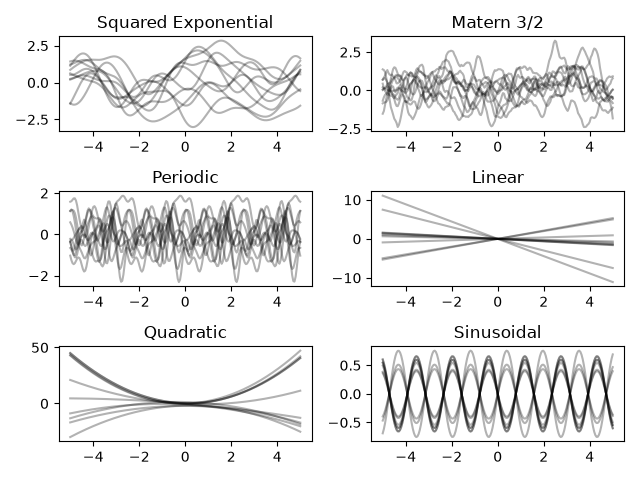

In [ ]:
# Sample from some kernels

x = jnp.linspace(-5.0, 5.0, 200)

k_se = SE(1.0, 0.5)
k_mat = Mat32(1.0, 0.5)
k_per = Periodic(1.0, 0.5, 2.5)
k_lin = Linear(1.0)
k_quad = Linear(1.0, lambda xx: xx ** jnp.arange(3))
k_sin = Linear(1.0, lambda xx: jnp.sin(4 * xx))
kerns = [
    ("Squared Exponential", k_se),
    ("Matern 3/2", k_mat),
    ("Periodic", k_per),
    ("Linear", k_lin),
    ("Quadratic", k_quad),
    ("Sinusoidal", k_sin),
]


def sample_kernel(
    key: jr.PRNGKey, kernel: Kernel, x: jnp.ndarray, nsamp: int = 10
) -> jnp.ndarray:
    gp_prior = MultivariateGaussian(jnp.zeros((x.shape[0])), covariance(kernel)(x, x))
    return gp_prior.sample(key, nsamp=nsamp)


# Plot samples from different covariance functions (zero mean)
fig = plt.figure()
ax = fig.subplots(3, 2)
for i, (nme, kk) in enumerate(kerns):
    plt_idx = (i // 2, i % 2)
    key, ys = sample_kernel(key, kk, x)
    ax[*plt_idx].plot(x, ys.T, "k", alpha=0.3)
    ax[*plt_idx].set_title(nme)

plt.tight_layout()


### Kernel Composition

We can also compose kernels either by addition or by element-wise multiplication as discussed above. There is some nice discussion in the [Kernel Cookbook](https://www.cs.toronto.edu/~duvenaud/cookbook/) which does a similar thing to this section of the notebook. I would say that some of the discussion there is a little dated now (particularly on the software recommendations) but the core concepts remain solid.

We will use similar examples to those in the cookbook for our kernel compositions.

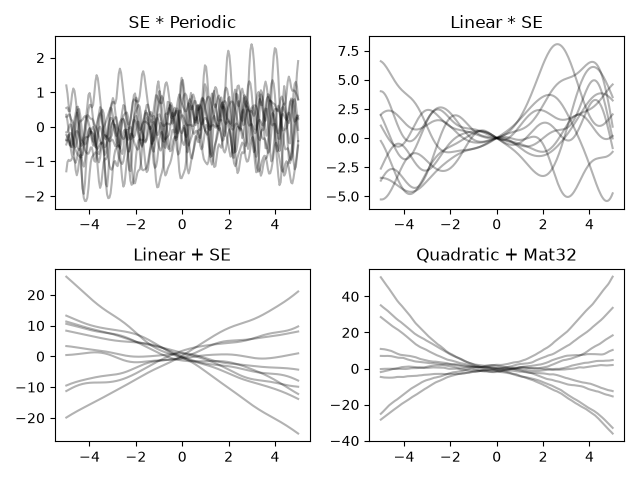

In [7]:
k_per_se = ProductKernel(SE(1.0, 10.0), Periodic(0.5, 1.0, 1.0))
k_lin_se_times = ProductKernel(SE(1.0, 1.0), Linear(1.0))
k_lin_se_add = SumKernel(SE(1.0, 1.0), Linear(4.0))
k_per_mat = SumKernel(k_quad, Mat32(0.5, 0.75))

comb_kerns = [
    ("SE * Periodic", k_per_se),
    ("Linear * SE", k_lin_se_times),
    ("Linear + SE", k_lin_se_add),
    ("Quadratic + Mat32", k_per_mat),
]

# Plot samples from different covariance functions (zero mean)
fig = plt.figure()
ax = fig.subplots(2, 2)
for i, (nme, kk) in enumerate(comb_kerns):
    plt_idx = (i // 2, i % 2)
    key, ys = sample_kernel(key, kk, x)
    ax[*plt_idx].plot(x, ys.T, "k", alpha=0.3)
    ax[*plt_idx].set_title(nme)

plt.tight_layout()

## Mean Functions

The discussion of mean functions can be much less involved than for the covariance functions, partly because most people find this more intuitive part of the model description. The mean function should encode what the average trend of our functions would be under only prior knowledge, i.e. before we see any data. It will not be directly conditioned on any observed data instead we will typically need to specify or learn its parameters (if there are any). We can, therefore, any mean function $m(x): \mathbb{R}^D \rightarrow \mathbb{R}$ which we like, e.g. a zero mean, constant value, linear trend or we can be more "exotic" things like empirical physical laws or even we could put a neural network!

Below we have provided some very common simple mean functions which may be useful. However think if there are any other useful mean behaviours which you might want to encode. 

For programming any new mean functions, we provide just the `__call__` method which should operate on a single input datapoint and return an array which has size `( )` or `(1,)`, i.e. just a scalar value. Later, as with the covariance we will use `vmap` to evaluate the mean function over the full input set.

In [ ]:
class ZeroMean(eqx.Module):
    """Zero Mean Function.

    Returns a static mean of zero for all input locations.
    """

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: A vector of zeros of shape (N,).
        """
        return jnp.array([0.0])


class ConstantMean(eqx.Module):
    """Constant Mean Function.

    Returns a static mean for all input locations.
    """

    c: float

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: A vector of zeros of shape (N,).
        """
        return jnp.array([self.c])


class LinearMean(eqx.Module):
    """Linear Basis Mean Function.

    Covariance for all models we can write as:
        k(x,x') = \\sigma_f^2 <\\phi(x), \\phi(x')>

    Including linear, polynomial etc.

    Hyperparameters:
        - w (jnp.ndarray): Weight vector of shape (F,).
        - basis (Callable): Feature mapping function phi(x) that maps
                            an (N, D) input to an (N, F) feature matrix.
    """

    w: jnp.ndarray
    basis: Callable[[jnp.ndarray], jnp.ndarray] = lambda xx: xx

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: Linear mean predictions of shape (N,).
        """
        return jnp.dot(jnp.atleast_1d(self.basis(x)), self.w)


MeanFunction = ZeroMean | ConstantMean | LinearMean

## Exact GP Inference

We have now put in place the ingredients to construct a Gaussian process - the mean function and the covariance function.

Now we can construct the code which we need to make use of the GP by conditioning it on some training data.

To make things work nicely with JAX we will split things up into a few different operations:
1. Computing an object which holds the current "state" of the GP
2. Making predictions of the full joint distribution of $f(x^\star)$ for a new set of inputs $x^\star$ including the cross covariance $K_{f^\star f^\star}$
3. Making predictions of the marginal distributions of $f(x^\star)$, only computing the diagonal of $K_{f^\star f^\star}$
4. Calculating the negative log marginal likelihood $-\log p(y|X)$ which we will use later to tune our hyperparameters

Begin by considering some notation:
$$
\begin{aligned}
    \left[K_{ff}\right]_{ij} = k(x_i, x_j)\\
    \left[K_{f^\star f}\right]_{ij} = k(x^\star_i, x_j)\\ 
    \left[K_{f^\star f^\star}\right]_{ij} = k(x^\star_i, x^\star_j)\\
    K_{ff} = L_{ff} L_{ff}^\text{T}\\
    \left[m_f\right]_i = m(x_i)\\
    \left[m_{f^\star}\right]_i = m(x^\star_i)\\
\end{aligned}
$$

Remember our calculation of the predictive distribution

$$
\begin{aligned}
    \mathbb{E}\left[f(x^\star)\right] &= K_{f^\star f} K^{-1}(y-m_f) = K_{f^\star f} (L_{ff}^{-\text{T}}L_{ff})(y-m_f) = K_{f^\star f}\alpha\\
    \mathbb{V}\left[f(x^\star)\right] &= K_{f^\star f^\star} - K_{f^\star f}K_{ff}^{-1}K_{ff^\star} = K_{f^\star f^\star} - \underbrace{\left[K_{f^\star f}L_{ff}^{-\text{T}}\right]}_{R^\text{T}}\left[L_{ff}^{-1}K_{ff^\star}\right]
\end{aligned}
$$

We expand these expressions using the Cholesky factorisations of $K_ff = L_{ff}L_{ff}^\text{T}$ since this will be useful in computing the state of our GP. Also note that our expression here is using the "noise-free" form of the GP where we don't have our observations corrupted by any measurement noise. This is the case in the setting of emulating a computer experiment which is *deterministic* and therefore commonly assumed if we are running, e.g. CFD/FEM.

One thing to note, despite the fact that our kernels are guaranteed to be positive definite by construction, implying that the Cholesky decomposition of $K_{ff}$ is available, in practice we run into floating point precision issues in the actual calculation of $L_{ff}$. To alleviate this we will make use of a *nugget* which is to add a small value along only the diagonal of $K_{ff}$ before we perform the Cholesky decomposition. Be aware that this can impact the result of the GP so you should be a bit careful. We also can note that if we are not in the emulator setting and there is some measurement noise, this is incorporated in the same way by additing some $\sigma_n^2\mathbb{I}$ to $K_ff$ which is commonly termed $\tilde{K}$. We can also achieve the exact same thing by defining our kernel to be the summation of the chosen kernel with a white noise kernel.

Since our predictions only require us to have access to $\alpha$ and also $L_{ff}$ we will keep these quantities stored in our state so we don't need to recompute the Cholesky decomposition of $K_{ff}$ for each new prediction set (this is the $\mathcal{O}(N^3)$ operation) which means that our predictions can be computed in $\mathcal{O}(N)$ time for the mean prediction and $\mathcal{O}(N^2)$ for the variance. We will store these two quantities in an `ExactGPState` object.

In [ ]:
# GP Functions


class ExactGPState(eqx.Module):
    """State of GP

    We can precompute and store the cholesky factor of \\tilde{K} and the
    "Woodbury" coefficients \\tilde{K} \\alpha = y computed by backsubstitution

    """

    L: jnp.ndarray  # Lower Cholesky of \tilde{K} = K_{ff} (+ \sigma_n^2 I)
    alpha: jnp.ndarray


Now we can move on to the business end of our GP.

### Updating the State

Whenever we modify our GP, e.g. changing the kernel (including its hyperparameters), we need to recompute the current state object. 

As discussed we need to compute two objects in our state, the "Woodbury" coefficients $\alpha$ and the lower Cholesky factor of $K_{ff}$.

In practice we will first compute the Cholesky factor then use this to compute $\alpha$. We will avoid computing the solution of 

$$
K_{ff}\alpha = y - m_f
$$

directly. Instead we will perform two triangular solves using backsubstitution (`jax.scipy.linalg.solve_triangular`) to get

$$
\alpha = L_{ff}^{-\text{T}}L_{ff}^{-1}(y-m_f)
$$

This has two advantages: firstly, it is two $\mathcal{O}(N^2)$ operations given that we already did the hard work to get $L_{ff}$; secondly, it will preserve the symmetry and positive definiteness of the inverse. 

### Predictive Distributions

Now we have computed the state of the GP by caching $L_ff$ and $\alpha$ we can use these in our predictions.

For our prediction functions we follow these steps:
1. For the new $X_\star$ calculate $K_{f^\star f}$ and $K_{f^\star f^\star}$
2. Compute our mean prediction $m_{f_\star} + K_{f^\star f}\alpha$
3. Compute the variance $K_{f^\star f^\star} - R^\text{T}R$ with $R = L_{ff}^{-1}K_{ff^\star}$ by `triangular_solve`

If we only care about the marginal distribution over the predictions then we can avoid some wasted work and our predictive variance is the diagonal of $K_{f^\star f^\star}$ minus the diagonal of $R^\text{T}R$. We use the `diagonal_covariance` function we made earlier for the first of these terms. There is one additional trick which we can use to get to the diagonal of $R^\text{T}R$. We can take the element-wise square of the matrix $R$ and then sum over the rows.

```{python}
(R.T@R).diagonal() = (R**2).sum(1)
```

### Hyperparameter Learning

Up until now we have not addressed how to set the hyperparameters of our kernels (or maybe the parameters of the mean functions if we don't know these in advance). Although our GP is *nonparametric* in practice it can be very beneficial to adjust these *hyperparameters* to best suit our data. If the covariance function defines the family of functions which our GP can model then the hyperparameters tell us the characteristics of that family. 

There are quite a few options for what we can do with the hyperparameters of the model:
1. Choose them *a priori* and leave them alone
2. Optimise them with respect to maximising the marginal likelihood of the GP $p(y|X)=\int p(y|f, X)p(f|X) \text{d}f$ - we often lean on the [Bayesian Occam's Razor](https://mlg.eng.cam.ac.uk/pub/pdf/RasGha01.pdf) to justify this as a "Type-II Maximum Likelihood" problem.
3. Include some prior knowledge and optimise the *maximum a posteriori* estimate by also including a prior $p(\phi)$ over the hyperparameters $\phi$
4. Be more Bayesian and try to infer $p(\phi | \mathcal{D})$ -  this must be approximated, e.g. by MCMC

By optimising against the marginal likelihood, we are evaluating the ability of the GP to fit the data which we have observed and we marginalise out all the possible functions which could pass through that data. In other words we are checking how good the infinite set of functions in the prior distribution can explain the full set of data we have seen so far. 

This sounds daunting but we can find this quantity in closed form for a GP with a normal likelihood. In fact it amounts to evaluating the likelihood of the observed targets $y$ given the multivariate Normal prior at the training input points $\mathcal{N}(m_f, K_{ff}). We will normally pose the optimisation as a minimisation of the *negative log marginal likelihood* 

$$
NLML = -\log p(y|X) = \frac{N}{2}\log(2\pi) + \frac{1}{2}\log \vert K_{ff} \vert + \frac{1}{2}(y-m_f)^\text{T}K_{ff}^{-1}(y-m_f)
$$

We can additionally use the state which we have precomuted here as well, noticing that 

$$
\frac{1}{2}\vert K_{ff} \vert = \sum_{i=1}^N \log \left[L_{ff}\right]_{ii}
$$

And using the state in computing the square form term at the end.

### Implementation

Below we implment these concepts into a `ExactGP` object which we initalise by passing in a mean function and a covariance kernel.

In [ ]:
class ExactGP(eqx.Module):
    """Exact Gaussian Process Regression Model.

    Work with GP models for

    y = f(x), f(x) ~ GP( m(x), k(x, x') )

    """

    mean: MeanFunction
    kernel: Kernel

    def update_state(self, x: jnp.ndarray, y: jnp.ndarray) -> ExactGPState:
        """Compute GP state from training data.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            y (jnp.ndarray): Training targets of shape (N, ).

        Returns:
            ExactGPState: State containing important variables.
        """
        N = x.shape[0]
        # Compute the training covariance matrix with a nugget for numerical stability
        ktilde = covariance(self.kernel)(x, x) + NUGGET * jnp.identity(N)
        L = jnp.linalg.cholesky(ktilde)

        # Compute alpha = K^-1 * y via back-substitution: L^T * L * alpha = y - m(x)
        y -= vmap(self.mean)(x).squeeze()
        alpha = solve_triangular(
            L, solve_triangular(L, y, lower=True), lower=True, trans=True
        )

        return ExactGPState(L, alpha)

    def predict(
        self, x: jnp.ndarray, xs: jnp.ndarray, state: ExactGPState
    ) -> MultivariateGaussian:
        """Compute full posterior predictive

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            xs (jnp.ndarray): Test inputs of shape (Ns, D).
            state (ExactGPState): GP state from `update_state`.

        Returns:
            MultivariateGaussian: posterior predictive
        """
        cov = covariance(self.kernel)
        ksx = cov(xs, x)
        kss = cov(xs, xs)

        # m = m(xs) + K_sx * K_xx^-1 * y = m(xs) + K_sx * alpha
        m = vmap(self.mean)(xs).squeeze() + ksx @ state.alpha

        # v = K_ss - K_sx * K_xx^-1 * K_xs
        R = solve_triangular(state.L, ksx.T, lower=True)
        v = kss - R.T @ R

        return MultivariateGaussian(m, v)

    def predict_marginal(
        self, x: jnp.ndarray, xs: jnp.ndarray, state: ExactGPState
    ) -> DiagonalGaussian:
        """Compute marginal predictive

        Often we don't need the cross covariance of the predictive so
        it is more efficient to only compute the diagonal

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D)
            xs (jnp.ndarray): Test inputs of shape (Ns, D)
            state (ExactGPState): GP state from `update_state`

        Returns:
            DiagonalGaussian: marginal posterior distributions
        """
        ksx = covariance(self.kernel)(xs, x)
        kss = diagonal_covariance(self.kernel)(xs)  # Only pull diagonal elements

        m = vmap(self.mean)(xs).squeeze() + ksx @ state.alpha

        R = solve_triangular(state.L, ksx.T, lower=True)
        v = kss - (R**2).sum(0)

        return DiagonalGaussian(m, v)

    def nlml(self, x: jnp.ndarray, y: jnp.ndarray, state: ExactGPState) -> jnp.ndarray:
        """Negative Log Marginal Likelihood

        Args:
            x (jnp.ndarray): Training inputs (N, D).
            y (jnp.ndarray): Training targets (N, ).
            state (ExactGPState): GP state from `update_state`.

        Returns:
            jnp.ndarray: negative log marginal likelihood (scalar)
        """
        N = x.shape[0]
        R = solve_triangular(state.L, y - vmap(self.mean)(x).squeeze(), lower=True)

        # N/2 log(2π) + 0.5 log |Ktilde| + 0.5 *(y' Ktilde^-1 y)
        return (
            N / 2 * jnp.log(2 * jnp.pi)
            + jnp.log(state.L.diagonal()).sum()
            + (R**2).sum() / 2
        )

Here we just provide a helper function which lets us plot the predictions of GPs. It plots out the variance as a shaded region, be aware that this is maybe a distorted view of the uncertainty and realistically the GP is composed of many possible functions. 

In [10]:
def plot_gp(
    x: jnp.ndarray,
    y: jnp.ndarray,
    posterior: Union["MultivariateGaussian", "DiagonalGaussian", "IsotropicGaussian"],
    ax: Optional[plt.Axes] = None,
    nsig: Union[float, int] = 3,
) -> None:
    """
    Plots the true data, the GP mean prediction, and a shaded uncertainty region.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    classname = type(posterior).__name__

    if "Multivariate" in classname:
        std = jnp.sqrt(posterior.sigma.diagonal())
    elif "Diagonal" in classname:
        std = jnp.sqrt(posterior.sigma)
    elif "Isotropic" in classname:
        std = jnp.sqrt(posterior.sigma) * jnp.ones_like(posterior.mu)
    else:
        raise TypeError(f"Unsupported posterior distribution type: {classname}")

    x_plot = jnp.atleast_1d(x).squeeze()
    mean_plot = jnp.atleast_1d(posterior.mu).squeeze()
    std_plot = jnp.atleast_1d(std).squeeze()

    lower_bound = mean_plot - nsig * std_plot
    upper_bound = mean_plot + nsig * std_plot

    ax.plot(x, y, color="black", linestyle="--", label="Observed Data")
    ax.plot(x_plot, mean_plot, color="tab:blue", lw=2, label="GP Mean")

    ax.fill_between(
        x_plot,
        lower_bound,
        upper_bound,
        color="tab:blue",
        alpha=0.2,
        label=f"±{nsig} Std. Dev.",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)

## Hyperparameter Optimisation - Part II

We can now revisit actually optimising the hyperparameters. The problem we are solving is as follows for a set of hyperparameters $\phi$,

$$
\hat{\phi} = \underset{\phi}{\mathrm{argmin}} -\log p(y | X)
$$

We will solve this optimisation problem as in the usual modern way, by performing gradient descent on the objective which we can compute using "automatic differentiation". Since we have already defined our function for the negative log marginal likelihood above we are able to get its gradient very easily from JAX by calling `grad(cost)` if we wrap up our cost calculation in the function `cost`. This is another higher order function which will itself return a function that gives us the gradient of `cost`. In practice we will actually use `value_and_grad` which behaves very predictably.

Unless you are very interested in how these things can be realised in JAX, you can safely ignore the details of implementing the `fit` function below and remain happy that this solves the above optimisation problem when you pass in the `data` as a tuple of $X$ and $y$, the `gp` object which is our `ExactGP` defined above and instantiated with a mean and covariance, and an optimiser from `optax` (we are using `optax.adam` here but see [Optax Documentation](https://optax.readthedocs.io/en/latest/)). 

A lot of the mess in this function comes from making sure we only take gradients with respect to the parameters of the model which we would like to modify, i.e. only the hyperparameters (and by default any parameters of the mean function). We also use a *softplus* transformation on the hyperparameters to ensure that that always remain positive. This is almost essential if you want the training loop to remain stable. You don't have to use a softplus here, any bijective mapping can be used that keeps the values positive, e.g. you could just do $\phi^2$ and $\sqrt{\phi}$, but softplus seems to lead to quite stable trainig dynamics. 

In broad steps:
1. We split up the model into the parts we want to train and the parts we want to leave fixed
2. We define a cost function `_cost` which takes the current transformed hyperparameters, maps them back to their positive values, recomputes the GP state, uses this to return the negative log marginal likelihood.
3. We wrap this so we have a function which only takes the trainable part of our model as an input
4. We compute gradients (and value) with respect to this 
5. We use a JAX scan loop to take repeated optimisation steps updating the parameters and logging the NLML at each epoch

ExactGP(
  mean=LinearMean(w=Array(1.48145665, dtype=float64)),
  kernel=SE(
    sf2=Array(2.67446617, dtype=float64), ll=Array(0.91494248, dtype=float64)
  )
)


Text(0, 0.5, 'NLML')

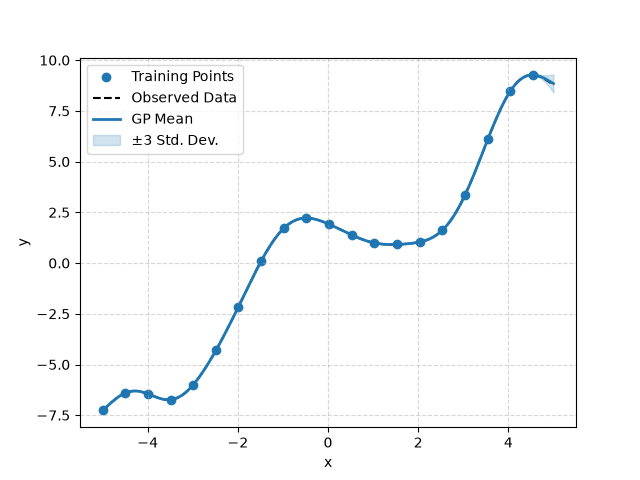

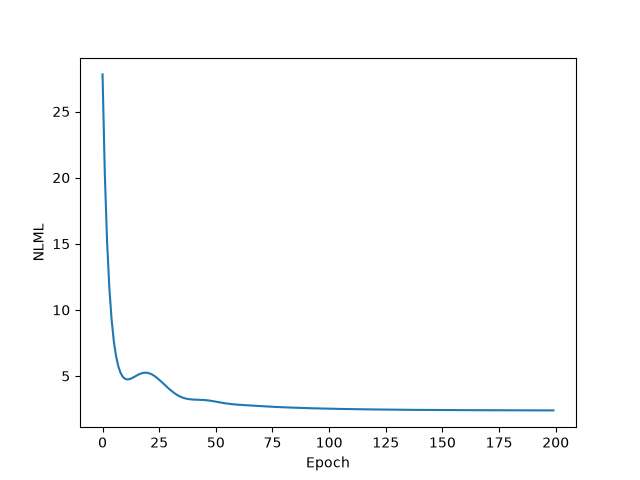

In [ ]:
# GP Hyperparameter Optimisation


def fit(
    data: Tuple[jnp.ndarray, jnp.ndarray], gp: ExactGP, opt, max_iters: int = 200
) -> Tuple[ExactGP, jnp.ndarray]:
    """Fits an Exact Gaussian Process model by optimizing its hyperparameters.

    This function optimises the trainable parameters of an `ExactGP` model by
    minimizing its Negative Log Marginal Likelihood (NLML). It features specific
    handling for kernel stability and parameter constraints:

    1. Parameter Freezing: we don't train the period of periodic kernels
    2. Unconstrained Optimization: we softplus all kernel hyperparameters

    Args:
        data: tuple containing the training data (x, y), shape (N, D), (N, )
        gp: an instance of `ExactGP` to be optimised
        opt: an Optax optimizer instance (e.g., `optax.adam`).
        max_iters: number of optimization steps to perform. Defaults to 200.

    Returns:
        Tuple containing:
            - ExactGP: The optimized Gaussian Process model with updated
            hyperparameters.
            - jnp.ndarray: A record of the loss values (NLML) across all iterations.
    """

    # We never want the period of the periodic kernel to be trained... too unstable.
    trainable, static = eqx.partition(
        gp,
        jax.tree.map_with_path(
            lambda pp, ll: (
                True if pp[-1].name != "pp" and eqx.is_array_like(ll) else False
            ),
            gp,
        ),
    )

    # Apply positive transform on kernel hyperparameters.
    transform_mask = jax.tree_util.tree_map(lambda _: False, trainable)
    transform_mask = eqx.tree_at(
        lambda m: m.kernel,
        transform_mask,
        replace_fn=lambda subtree: jax.tree.map(eqx.is_array_like, subtree),
    )

    # Softplus and inverse for our positive only hyperparameters
    def _param_mapping(tree):
        return jax.tree.map(
            lambda x, mask: jnp.log(1 + jnp.exp(x)) if mask else x, tree, transform_mask
        )

    def _inv_param_mapping(tree):
        return jax.tree.map(
            lambda x, mask: jnp.log(jnp.exp(x) - 1) if mask else x, tree, transform_mask
        )

    # Move parameters to training space
    trainable = _inv_param_mapping(trainable)

    # Training objective: remap parameters, update GP, compute marginal likelihood
    def _cost(trainable: ExactGP, static: ExactGP):
        trainable = _param_mapping(trainable)
        model = eqx.combine(trainable, static)
        state = model.update_state(*data)
        cost = model.nlml(*data, state)
        return cost

    # Actual value and gradient calculation only on trainable part
    _cost_frozen = jax.value_and_grad(jax.jit(partial(lambda tt: _cost(tt, static))))

    # Optimisation step
    def _step(carry, xs):
        train, opt_state = carry
        v, g = _cost_frozen(train)
        updates, opt_state = opt.update(g, opt_state)
        train = optax.apply_updates(train, updates)
        return (train, opt_state), v

    # Perform the optimisation for max_iters epochs
    opt_state = opt.init(trainable)
    (trainable, opt_state), cost_log = jax.lax.scan(
        _step, (trainable, opt_state), None, length=max_iters
    )

    # Rebuild the model before returning
    return (eqx.combine(_param_mapping(trainable), static), cost_log)


## Our First GP

Ok now we can finally fit a GP... 

We will begin by sampling a function from a GP then proving that we can predict that function if we have only seen a few points from it. 

You can see this process below.

In [ ]:
# Set up a GP
m = LinearMean(jnp.array(1.2))
k = SE(3.0, 0.9)
# k = Periodic(3.0, 1.0, 3.0)
gp = ExactGP(m, k)

# Sample from the GP then learn it
x = jnp.linspace(-5.0, 5.0, 200)
key, y = sample_kernel(key, k, x, 1)
y = vmap(m)(x).squeeze() + y.squeeze()

# Take every 10th point
xtr = x[::10]
ytr = y[::10]


# Plot our training data
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(xtr, ytr, label="Training Points")

# User Adam as our optimiser, doesn't matter too much
opt = optax.adam(5e-2)

# Make some initial hyperparameters all 1.0 - usually just set as you build the GP
# here it is silly to start where we know the "true" hyperparameters
gp0 = jax.tree.map_with_path(
    lambda pp, xx: 1.0 if eqx.is_array_like(xx) and pp[-1].name != "pp" else xx, gp
)

# Fit the GP
gp_opt, cost_log = fit((xtr, ytr), gp0, opt)

# Predict over the whole dataset
gp_state = gp_opt.update_state(xtr, ytr)
posterior_predictive = gp_opt.predict_marginal(xtr, x, gp_state)

# Plot our predictions
plot_gp(x, y, posterior_predictive, ax, 3)

# Print out the optimised GP model
eqx.tree_pprint(gp_opt, short_arrays=False)

# Also plot the progression of our loss function
plt.figure()
plt.plot(cost_log)
plt.xlabel("Epoch")
plt.ylabel("NLML")

## CHF Data

Now let's extend to look at the CHF data. From this point on we would strongly promote messing around with what variables you include in the model, the choice of kernel, specification of different mean functions etc.

Step one we will pull in the dataset which has been divided out for this session `chf_gp.csv`

First of all we will check that this notebook can see the data files and load in this dataset.

In [12]:
DATA_PATH = "../../../data"

# Check we can access data appropriately
try:
    print(f"Available Data: {', '.join([f for f in os.listdir(DATA_PATH)])}")
except FileNotFoundError:
    print(
        f"""
        Data files not available at path: {DATA_PATH}. \n
        Check your working directory, currently you are in {os.getcwd()}\n
        You are expected to be in ...nth-summer-school/ai4nth-summer-school/course_materials/day3_surrogates_gp/solutions for relative path to work.
        """
    )

df = pd.read_csv(DATA_PATH + "/chf_GP.csv", sep=",", header=0)

# Print out the top rows of our "GP" dataset to see what we've got.
display(df.head())


Available Data: chf_OOD_Kim2000.csv, chf_OOD_Lee1966.csv, chf_val.csv, chf_GP.csv, chf_OOD_Peterlongo1966.csv, chf_ong.csv, chf_test.csv, chf_train.csv


,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
0,3387,13,0.01,1.0,9800.0,570.0,0.421,923.0,111.88,2095.0,Alekseev 1954
1,3388,13,0.01,1.0,9800.0,676.0,0.378,898.0,117.82,2351.0,Alekseev 1954
2,3389,13,0.01,1.0,9800.0,849.0,0.291,884.0,121.14,2678.0,Alekseev 1954
3,3390,13,0.01,1.0,9800.0,941.0,0.247,866.0,125.40,2787.0,Alekseev 1954
4,3391,13,0.01,1.0,9800.0,970.0,0.238,921.0,112.36,2976.0,Alekseev 1954


## An Example to Build On

So, being honest, I ([Tim](https://scholar.google.com/citations?user=k2ZHf3cAAAAJ&hl=en)) know very little about NTH! Bearing that in mind we can begin building up an emulator to try and model the CHF data which is provided. 

Before writing this example, I have spend some time trying to visualise the data and see correlations between different variables. Where this model is quite lacking is that I am sure better physical prior knowledge could be applied in setting up a good mean function and covariance structure but let's have a go. 

To make things a bit clearer we will look only at one tube diameter and one heated length to begin with. We note there are very few unique values for these quantities in this dataset which will be limiting in building any kind of sensible model over them. This is not really a limitation of choosing a GP emulator but more that we don't have control over getting a good representative coverage of the input space. 

Also I had assumed since this was a surrogate session that these data had come from computer simulations which would be noise free (and I would expect would have more variation in these parameters) but, looking at the references, perhaps these are experimental data and the noise free assumption might be misguided. We can always test this by adding a white kernel on top of our chosen structure.

We are going to fit a relatively simple model here which takes four inputs and targets CHF as the output. Let's start off by just visualisng 

Using 500/571 datapoints for training.


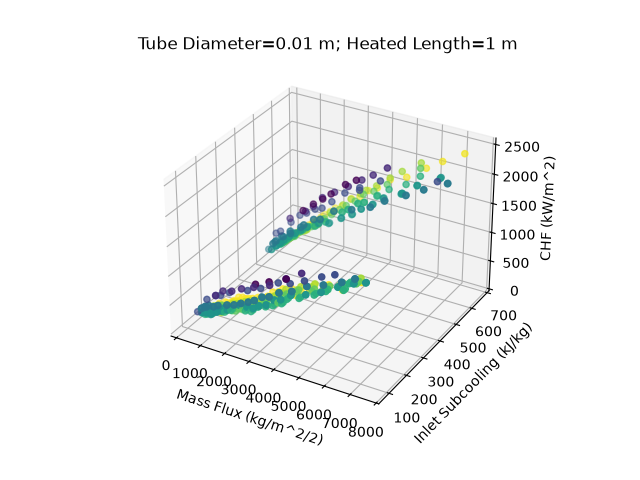

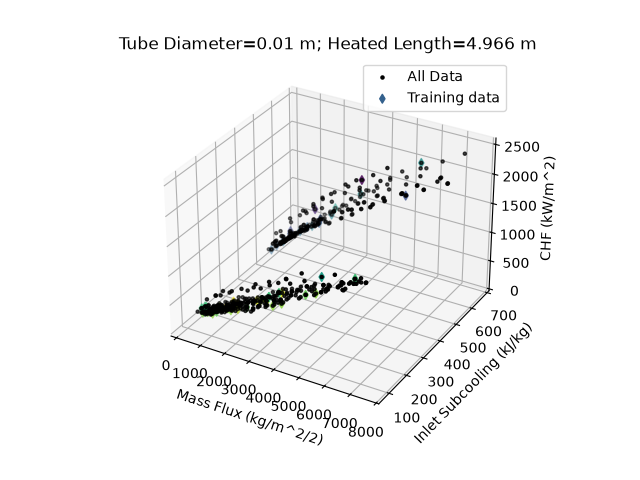

In [ ]:
# Only look in these conditions
tube_diam = ("Tube Diameter (m)", 0.01)
heated_length = ("Heated Length (m)", 4.966)
pressure = ("Pressure (kPa)", 0)  # Use all pressures


# Then let's try look at the relationship MF, IS, Pressure -> CHF
fd = df[(df[heated_length[0]] == heated_length[1]) & (df[pressure[0]] >= pressure[1])]
# fd = df.copy()

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(
    fd["Mass Flux (kg/m^2/s)"],
    fd["Inlet Subcooling (kJ/kg)"],
    fd["CHF (kW/m^2)"],
    c=fd["Pressure (kPa)"],
)
ax.set_xlabel("Mass Flux (kg/m^2/2)")
ax.set_ylabel("Inlet Subcooling (kJ/kg)")
ax.set_zlabel("CHF (kW/m^2)")
ax.set_title("Tube Diameter=0.01 m; Heated Length=1 m")


N_total = fd.shape[0]
N = 300
print(f"Using {N}/{N_total} datapoints for training.")
tr_idx = np.random.choice(fd.shape[0], (50,))

x = fd[
    [
        "Mass Flux (kg/m^2/s)",
        "Inlet Subcooling (kJ/kg)",
        "Inlet Temperature (degreeC )",
        "Pressure (kPa)",
    ]
].to_numpy()
y = fd["CHF (kW/m^2)"].to_numpy()
xtr = x[tr_idx]
ytr = y[tr_idx]


fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(x[:, 0], x[:, 1], y, c="k", marker=".", label="All Data")
ax.scatter(
    x[tr_idx, 0],
    x[tr_idx, 1],
    y[tr_idx],
    c=x[tr_idx, 2],
    marker="d",
    label="Training data",
)
ax.set_xlabel("Mass Flux (kg/m^2/2)")
ax.set_ylabel("Inlet Subcooling (kJ/kg)")
ax.set_zlabel("CHF (kW/m^2)")
ax.set_title(f"Tube Diameter=0.01 m; Heated Length={heated_length[1]} m")
plt.legend()


In [14]:
def plot_2d_gp(
    X: np.ndarray,
    y: np.ndarray,
    predict_fn: Callable[[np.ndarray], Any],
    grid_res: int = 50,
    padding: float = 0.5,
):
    """
    Plots a 3D surface of a 2-input GP model's mean and uncertainty alongside training data.

    Parameters:
    -----------
    X : np.ndarray
        Training inputs, shape (N, 2)
    y : np.ndarray
        Training targets, shape (N,)
    predict_fn : Callable[[np.ndarray], DiagonalGaussian]
        A function that accepts a (M, 2) test input array and returns
        the DiagonalGaussian object containing .mu and .sigma
    grid_res : int, optional
        Resolution of the prediction grid mesh (grid_res x grid_res), default is 50.
    padding : float, optional
        How far past the min/max training data points to extend the plot, default is 0.5.
    """
    # 1. Setup the Grid for Predictions
    x_bounds = [(X[:, i].min() - padding, X[:, i].max()) for i in range(X.shape[1])]

    x_grid = np.meshgrid(
        *[
            np.linspace(x_bounds[i][0], x_bounds[i][1], grid_res)
            for i in range(X.shape[1])
        ],
    )

    # Flatten grid for the prediction function
    X_test = np.vstack([xx.ravel() for xx in x_grid]).T

    # 2. Get GP Predictions via the callback
    prediction = predict_fn(X_test)

    # Reshape outputs back into 2D grid dimensions
    # Note: jnp arrays from Equinox/JAX convert cleanly to numpy via np.array
    mu_grid = np.array(prediction.mu).reshape(x_grid[0].shape)
    std_grid = np.sqrt(np.array(prediction.sigma)).reshape(x_grid[0].shape)

    # 3. 3D Plotting
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Scatter plot for training data
    ax.scatter(
        X[:, 0],
        X[:, 1],
        y,
        color="red",
        s=40,
        zorder=10,
        label="Training Data",
        edgecolor="k",
    )

    # Mean Prediction Surface
    surf = ax.plot_surface(
        x_grid[0],
        x_grid[1],
        mu_grid,
        cmap="viridis",
        alpha=0.6,
        linewidth=0,
        antialiased=True,
        label="Predicted Mean ($\\mu$)",
    )
    # Workaround for matplotlib surface legend bug
    surf._facecolors2d = surf._facecolor3d
    surf._edgecolors2d = surf._edgecolor3d

    # Uncertainty Bounds (95% Confidence Interval)
    ax.plot_surface(
        x_grid[0],
        x_grid[1],
        mu_grid + 2 * std_grid,
        color="gray",
        alpha=0.15,
        linewidth=0,
        antialiased=True,
    )
    ax.plot_surface(
        x_grid[0],
        x_grid[1],
        mu_grid - 2 * std_grid,
        color="gray",
        alpha=0.15,
        linewidth=0,
        antialiased=True,
    )

    # Labels and Styling
    ax.set_xlabel("Input Dimension 1 ($X_1$)")
    ax.set_ylabel("Input Dimension 2 ($X_2$)")
    ax.set_zlabel("Output ($y$)")
    ax.set_title("2D Input Gaussian Process Regression")
    ax.legend()

    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)

    plt.show()


In [15]:
class Normaliser(eqx.Module):
    @staticmethod
    def self_normalise(
        x: jnp.ndarray,
    ) -> Tuple[jnp.ndarray, Tuple[jnp.ndarray, jnp.ndarray]]:
        m = x.mean(0, keepdims=True)
        s = x.std(0, keepdims=True)

        return (x - m) / s, (m, s)

    @staticmethod
    def normalise(
        x: jnp.ndarray, scales: Tuple[jnp.ndarray, jnp.ndarray]
    ) -> jnp.ndarray:
        m, s = scales
        return (x - m) / s

    @staticmethod
    def denormalise(
        x: jnp.ndarray, scales: Tuple[jnp.ndarray, jnp.ndarray]
    ) -> jnp.ndarray:
        m, s = scales
        return x * s + m


ExactGP(
  mean=LinearMean(
    w=Array([ 0.92678388,  0.33288087, -0.22922422], dtype=float64)
  ),
  kernel=SumKernel(
    k1=SEARD(
      sf2=Array(0.07925202, dtype=float64),
      ll=Array([0.95767304, 1.97908159, 1.27348475], dtype=float64)
    ),
    k2=WhiteKernel(sn2=Array(0.00023377, dtype=float64))
  )
)
ExactGP(
  mean=LinearMean(
    w=Array([ 0.87559815,  0.31289932, -0.2212722 ], dtype=float64)
  ),
  kernel=WhiteKernel(sn2=Array(0.05494619, dtype=float64))
)
0.4587926604356532
4.9731087394862135


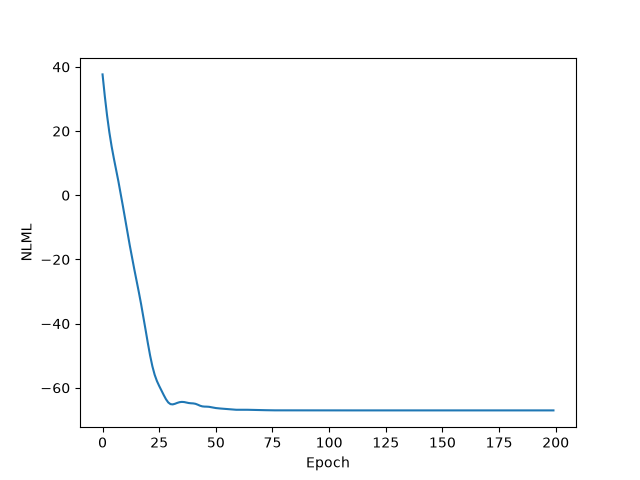

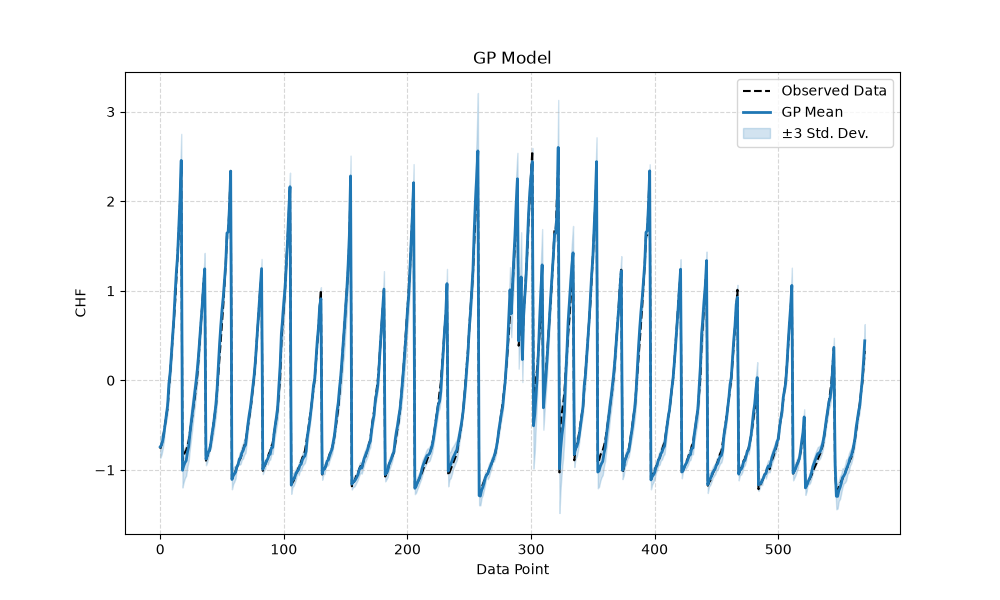

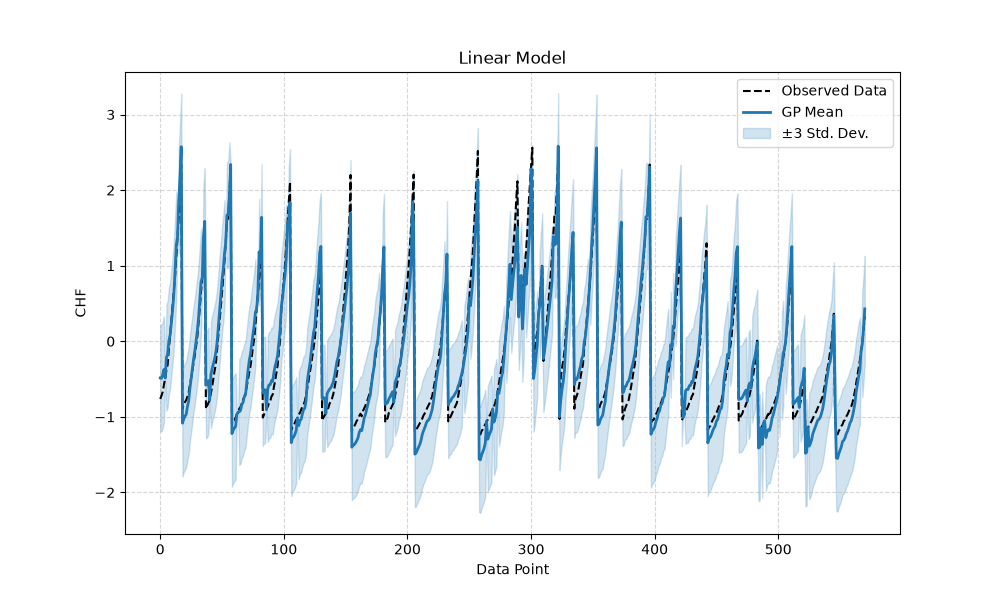

In [16]:
# Put everything in 0 mean, unit standard deviation
xtr_norm, x_norms = Normaliser.self_normalise(xtr)
ytr_norm, y_norms = Normaliser.self_normalise(ytr)

xtr_norm = xtr_norm[:, [0, 1, 3]]

x_test = Normaliser.normalise(x, x_norms)[:, [0, 1, 3]]
y_test = Normaliser.normalise(y, y_norms)


m = ZeroMean()
m = LinearMean(jnp.zeros((xtr_norm.shape[1],)))
k = SumKernel(
    SEARD(1.0, 0.1 * jnp.ones((xtr_norm.shape[1]))), WhiteKernel(1e-3)
)  # We have scaled to unit standard deviation...

gp = ExactGP(m, k)
opt = optax.adam(1e-1)

gp, cost_log = fit((xtr_norm, ytr_norm), gp, opt)

plt.figure()
plt.plot(cost_log)
plt.xlabel("Epoch")
plt.ylabel("NLML")

gp_state = gp.update_state(xtr_norm, ytr_norm)
posterior_predictive = gp.predict_marginal(xtr_norm, x_test, gp_state)

residual = jnp.sqrt((y_test - posterior_predictive.mu) ** 2)


eqx.tree_pprint(gp, short_arrays=False)

plot_gp(
    np.arange(y_test.shape[0]), y_test, gp.predict_marginal(xtr_norm, x_test, gp_state)
)
plt.title("GP Model")
plt.xlabel("Data Point")
plt.ylabel("CHF")

m2 = LinearMean(jnp.zeros((xtr_norm.shape[1],), dtype=jnp.float64))
k2 = WhiteKernel(1e-1)
gp2 = ExactGP(m2, k2)


gp2, _ = fit((xtr_norm, ytr_norm), gp2, opt)
eqx.tree_pprint(gp2, short_arrays=False)

plot_gp(
    np.arange(y_test.shape[0]),
    y_test,
    gp2.predict_marginal(xtr_norm, x_test, gp2.update_state(xtr_norm, ytr_norm)),
)
plt.title("Linear Model")
plt.xlabel("Data Point")
plt.ylabel("CHF")


def nmse(y, yp):
    return 100 / jnp.var(y) * jnp.mean((y - yp) ** 2)


print(
    nmse(
        y_test,
        gp.predict_marginal(xtr_norm, x_test, gp.update_state(xtr_norm, ytr_norm)).mu,
    )
)
print(
    nmse(
        y_test,
        gp2.predict_marginal(xtr_norm, x_test, gp2.update_state(xtr_norm, ytr_norm)).mu,
    )
)


,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
0,1650,9,0.00999,0.6,2991.0,220.0,0.751,839.0,39.61,2002.0,"Becker 1963 AE 114, 1965 AE-177"
1,1651,9,0.00999,0.6,2305.0,225.0,0.737,776.0,39.16,2009.0,"Becker 1963 AE 114, 1965 AE-177"
2,1652,9,0.00999,0.6,2599.0,221.0,0.750,812.0,37.54,2009.0,"Becker 1963 AE 114, 1965 AE-177"
3,1653,9,0.00999,0.6,2040.0,228.0,0.725,749.0,38.75,2006.0,"Becker 1963 AE 114, 1965 AE-177"
4,1654,9,0.00999,0.6,1775.0,228.0,0.726,717.0,38.86,1998.0,"Becker 1963 AE 114, 1965 AE-177"


N Training Data: (10424, 11)


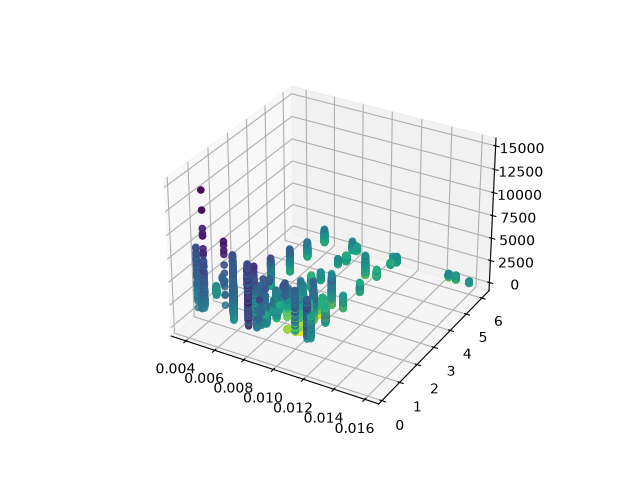

In [19]:
train = pd.read_csv(DATA_PATH + "/chf_train.csv", sep=",", header=0)
val = pd.read_csv(DATA_PATH + "/chf_val.csv", sep=",", header=0)
test = pd.read_csv(DATA_PATH + "/chf_test.csv", sep=",", header=0)

display(train.head())
print(f"N Training Data: {train.shape}")

xtr = train[
    [
        "Tube Diameter (m)",
        "Heated Length (m)",
        "Pressure (kPa)",
        "Mass Flux (kg/m^2/s)",
        "Inlet Subcooling (kJ/kg)",
        "Inlet Temperature (degreeC )",
    ]
]
ytr = train["CHF (kW/m^2)"]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(
    train["Tube Diameter (m)"],
    train["Heated Length (m)"],
    train["CHF (kW/m^2)"],
    c=train["Outlet Quality"],
)

xtr_norm, x_norms = Normaliser.self_normalise(xtr.to_numpy()[::10, :])
ytr_norm, y_norms = Normaliser.self_normalise(ytr.to_numpy()[::10,])

m = ZeroMean()  # LinearMean(jnp.zeros((xtr.shape[1])))
k = SumKernel(SEARD(1.0, jnp.ones((xtr.shape[1]))), WhiteKernel(1e-4))
gp = ExactGP(m, k)

# gp, cost_log = fit((xtr_norm, ytr_norm), gp, optax.adam(1e-2), max_iters=100)

# plt.figure()
# plt.plot(cost_log)
# plt.xlabel("Epoch")
# plt.ylabel("NLML")


ExactGP(
  mean=ZeroMean(),
  kernel=SumKernel(
    k1=SEARD(sf2=1.0, ll=Array([1., 1., 1., 1., 1., 1.], dtype=float64)),
    k2=WhiteKernel(sn2=0.0001)
  )
)
3.3503580020129973


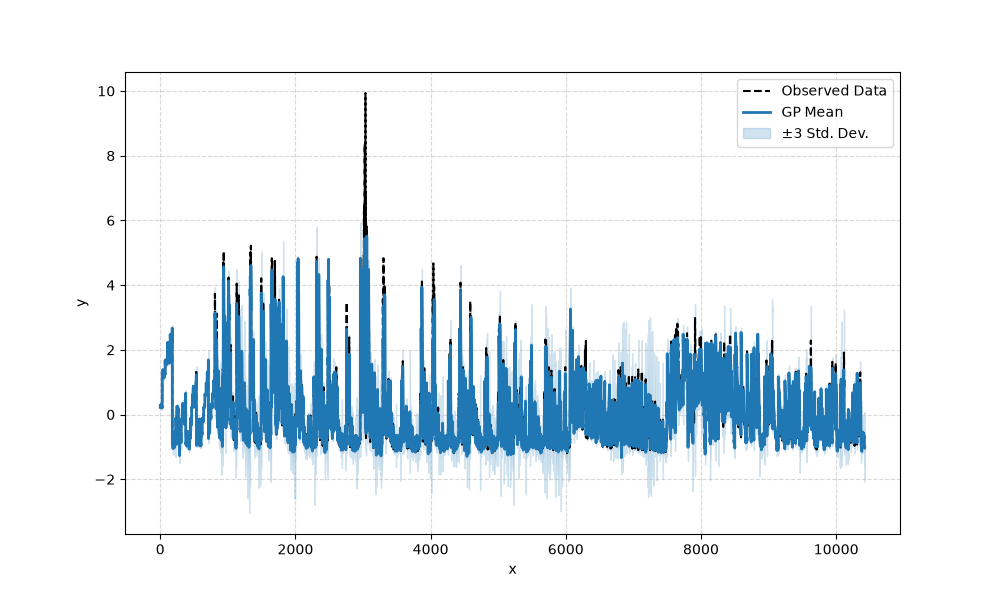

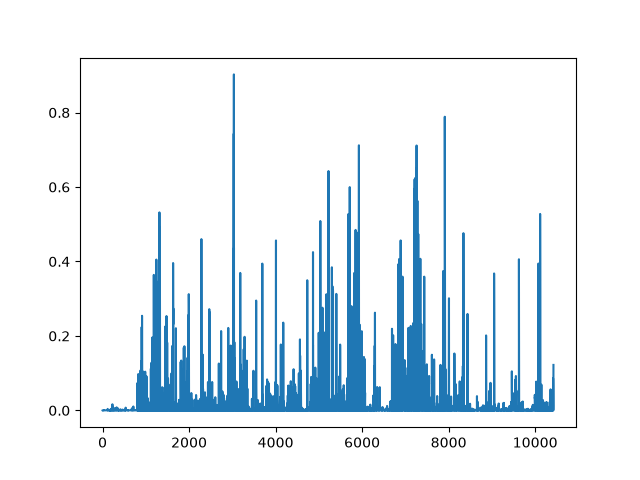

In [20]:
posterior_predictive = gp.predict_marginal(
    xtr_norm,
    Normaliser.normalise(xtr.to_numpy(), x_norms),
    gp.update_state(xtr_norm, ytr_norm),
)

plot_gp(
    np.arange(ytr.shape[0]),
    Normaliser.normalise(ytr.to_numpy(), y_norms),
    posterior_predictive,
)

eqx.tree_pprint(gp, short_arrays=False)
print(
    nmse(
        Normaliser.normalise(ytr.to_numpy(), y_norms),
        posterior_predictive.mu,
    )
)

plt.figure()
plt.plot(posterior_predictive.sigma)
